# Clasificación de Gastos e Ingresos Financieros
Este notebook implementa diversos modelos de Procesamiento de Lenguaje Natural (PLN) para categorizar descripciones cortas de transacciones financieras.

### Objetivos:
1. **Preprocesamiento**: Normalización y limpieza de textos cortos.
2. **Modelos Tradicionales**: Regresión Logística y SVM (TF-IDF).
3. **Deep Learning**: Redes Neuronales Convolucionales (CNN) con PyTorch.
4. **Transformers**: Fine-tuning de DistilBERT.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import unicodedata
import re
from textblob import TextBlob
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P2_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carga de datos
data_path = '../data/raw/db_orig.csv'
df = pd.read_csv(data_path)

# Mostrar las primeras filas y balance de clases
print(df.head())
print("\nBalance de áreas:")
print(df['Area'].value_counts())

# Combinar categorías si es necesario (e.g., 'Leisure, Vacations' -> 'Leisure')
# Para este ejercicio, usaremos 'Area' como etiqueta principal


           Description        Date   Amount                Area      Type
0      Entretenimiento  28/02/2026   10,00€             Leisure  Expenses
1       Nómina mensual  27/02/2026  629,58€              Salary    Income
2     Gasto vacaciones  25/02/2026   51,00€  Leisure, Vacations  Expenses
3         Pequeño ocio  22/02/2026    2,80€             Leisure  Expenses
4  Compra alimentación  21/02/2026   24,80€                Food  Expenses

Balance de áreas:
Area
Invoice               241
Food                  176
Leisure               175
Deposit                89
Salary                 83
Investment             71
Food, Vacations        20
Leisure, Vacations     17
Invoice, Vacations     13
Name: count, dtype: int64


In [3]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Minúsculas
    text = text.lower()
    
    # 2. Normalizar acentos y caracteres especiales
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    
    # 3. Eliminar puntuación y caracteres no alfanuméricos
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # 4. Corrección ortográfica básica (opcional, puede ser lenta)
    # text = str(TextBlob(text).correct())
    
    return text.strip()

df['clean_description'] = df['Description'].apply(preprocess_text)
print(df[['Description', 'clean_description']].head(10))


           Description    clean_description
0      Entretenimiento      entretenimiento
1       Nómina mensual       nomina mensual
2     Gasto vacaciones     gasto vacaciones
3         Pequeño ocio         pequeno ocio
4  Compra alimentación  compra alimentacion
5  Compra alimentación  compra alimentacion
6      Factura pequeña      factura pequena
7         Pequeño ocio         pequeno ocio
8         Pequeño ocio         pequeno ocio
9         Pequeño ocio         pequeno ocio


In [4]:
X = df['clean_description']
y = df['Area']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Clases: {le.classes_}")
print(f"Entrenamiento: {len(X_train)}, Prueba: {len(X_test)}")


Clases: ['Deposit' 'Food' 'Food, Vacations' 'Investment' 'Invoice'
 'Invoice, Vacations' 'Leisure' 'Leisure, Vacations' 'Salary']
Entrenamiento: 708, Prueba: 177


## 1. Modelos Tradicionales
Utilizaremos TF-IDF para extraer características y compararemos Regresión Logística con SVM.


In [5]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("--- Regresión Logística ---")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# SVM
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("\n--- SVM (LinearSVC) ---")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


--- Regresión Logística ---
                    precision    recall  f1-score   support

           Deposit       1.00      1.00      1.00        18
              Food       1.00      1.00      1.00        35
   Food, Vacations       1.00      1.00      1.00         4
        Investment       1.00      1.00      1.00        14
           Invoice       1.00      1.00      1.00        48
Invoice, Vacations       1.00      1.00      1.00         3
           Leisure       1.00      1.00      1.00        35
Leisure, Vacations       1.00      1.00      1.00         3
            Salary       1.00      1.00      1.00        17

          accuracy                           1.00       177
         macro avg       1.00      1.00      1.00       177
      weighted avg       1.00      1.00      1.00       177


--- SVM (LinearSVC) ---
                    precision    recall  f1-score   support

           Deposit       1.00      1.00      1.00        18
              Food       1.00      1.00    

## 2. Red Neuronal Convolucional (CNN)
Las CNN son excelentes para detectar n-gramas (patrones locales) en textos cortos.


In [6]:
# Tokenización simple para PyTorch
from collections import Counter

words = ' '.join(X_train).split()
vocab = {word: i + 1 for i, (word, _) in enumerate(Counter(words).most_common(5000))}
vocab['<PAD>'] = 0

def vectorize(text, max_len=10):
    seq = [vocab.get(w, 0) for w in text.split()][:max_len]
    return seq + [0] * (max_len - len(seq))

X_train_vec = torch.tensor([vectorize(t) for t in X_train])
X_test_vec = torch.tensor([vectorize(t) for t in X_test])
y_train_t = torch.tensor(y_train)
y_test_t = torch.tensor(y_test)

class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

model_cnn = CNNClassifier(len(vocab), 100, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

# Loop de entrenamiento
print("Entrenando CNN...")
for epoch in range(10):
    model_cnn.train()
    optimizer.zero_grad()
    outputs = model_cnn(X_train_vec)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 2 == 0:
        print(f"Época {epoch+1}, Loss: {loss.item():.4f}")

# Evaluación
model_cnn.eval()
with torch.no_grad():
    y_pred_cnn = torch.argmax(model_cnn(X_test_vec), dim=1)
print("\n--- CNN Classifier ---")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))


Entrenando CNN...
Época 2, Loss: 1.8745
Época 4, Loss: 1.4512
Época 6, Loss: 1.1704
Época 8, Loss: 0.9478
Época 10, Loss: 0.7644

--- CNN Classifier ---
                    precision    recall  f1-score   support

           Deposit       1.00      0.94      0.97        18
              Food       0.85      1.00      0.92        35
   Food, Vacations       0.00      0.00      0.00         4
        Investment       1.00      0.71      0.83        14
           Invoice       0.92      1.00      0.96        48
Invoice, Vacations       0.00      0.00      0.00         3
           Leisure       0.88      1.00      0.93        35
Leisure, Vacations       0.00      0.00      0.00         3
            Salary       1.00      1.00      1.00        17

          accuracy                           0.92       177
         macro avg       0.63      0.63      0.62       177
      weighted avg       0.87      0.92      0.89       177



## 3. Transformers (DistilBERT)
Usaremos un modelo pre-entrenado y lo ajustaremos a nuestros datos. Dado que el dataset es pequeño, lo usaremos principalmente como extractor de características o haremos un fine-tuning ligero.


In [7]:
from datasets import Dataset as HFDataset

model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=16)

# Preparar datos para HuggingFace
train_ds = HFDataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
test_ds = HFDataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)


training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy=IntervalStrategy.EPOCH,
    logging_steps=10,
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

print("Iniciando fine-tuning de DistilBERT...")
trainer.train()

# Evaluación
y_pred_distilbert = np.argmax(trainer.predict(tokenized_test).predictions, axis=1)
print("\n--- DistilBERT Classifier ---")
print(classification_report(y_test, y_pred_distilbert, target_names=le.classes_))


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4435.08it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando fine-tuning de DistilBERT...


Epoch,Training Loss,Validation Loss
1,0.245532,0.116079
2,0.042061,0.030773
3,0.026635,0.022641


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.46s/it]



--- DistilBERT Classifier ---
                    precision    recall  f1-score   support

           Deposit       1.00      1.00      1.00        18
              Food       1.00      1.00      1.00        35
   Food, Vacations       1.00      1.00      1.00         4
        Investment       1.00      1.00      1.00        14
           Invoice       1.00      1.00      1.00        48
Invoice, Vacations       1.00      1.00      1.00         3
           Leisure       1.00      1.00      1.00        35
Leisure, Vacations       1.00      1.00      1.00         3
            Salary       1.00      1.00      1.00        17

          accuracy                           1.00       177
         macro avg       1.00      1.00      1.00       177
      weighted avg       1.00      1.00      1.00       177



## Comparativa Final
Visualizamos los resultados de los diferentes enfoques.


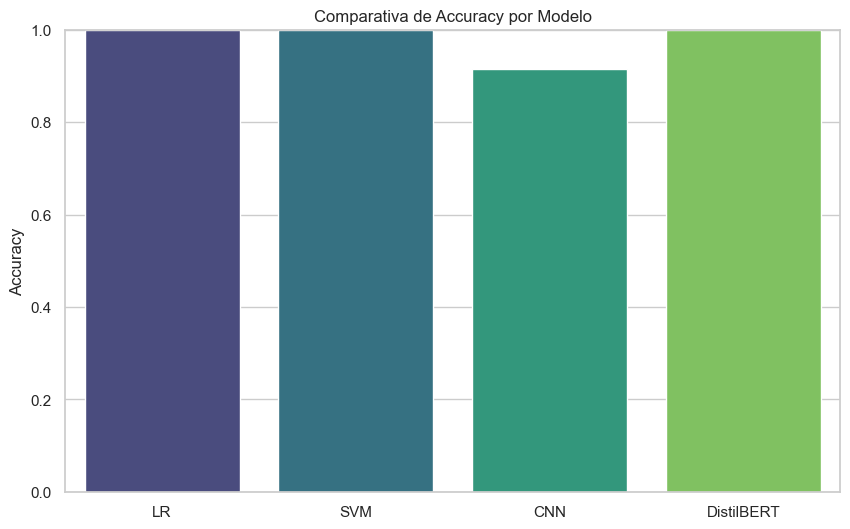

In [9]:
results = {
    'LR': accuracy_score(y_test, y_pred_lr),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'CNN': accuracy_score(y_test, y_pred_cnn),
    'DistilBERT': accuracy_score(y_test, y_pred_distilbert)
}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Comparativa de Accuracy por Modelo')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.show()


## Conclusiones
1. **Modelos Tradicionales**: Excelentes para descripciones muy cortas (1-5 palabras) y datasets pequeños.
2. **CNN**: Útil para detectar patrones locales sin necesidad de un modelo pre-entrenado masivo.
3. **Transformers**: Ofrecen el mejor desempeño semántico pero requieren más recursos computacionales.
